# 05 · Data Association
**Companion to the lecture:** *Data Association* — Florian Meyer, FUSION Boot Camp 2026.

> ⚠️ The slides for this lecture are **not** included in the PDF. This notebook is based on the canonical 
> literature (Bar-Shalom, Blackman & Popoli) and on the context Blasch provides in the introduction.

In notebook 03 we saw that the Kalman filter assumes **perfect measurement-to-track association**. In reality 
there are multiple targets, false measurements (clutter), and missed detections. Data association answers: 
**which measurement belongs to which track?**

## A. Gating and the Mahalanobis distance
Before association, we discard measurements too far from the prediction. The 'gate' is defined by the squared Mahalanobis distance:
$$d^2 = (z-\hat z)^T S^{-1} (z-\hat z) \le \gamma$$
where $S=HPH^T+R$ is the innovation covariance. $d^2$ is $\chi^2$-distributed with degrees of freedom equal to the measurement dimension.

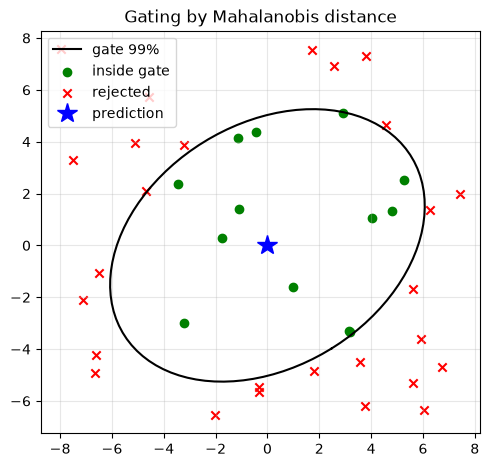

13 of 40 measurements entered the gate


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
rng = np.random.default_rng(3)

def maha2(z, zhat, S):
    d = (z - zhat).reshape(-1,1)
    return float((d.T @ np.linalg.inv(S) @ d).item())

# predicted target in the plane with innovation covariance S; chi2 gate with 2 dof, 99% -> 9.21
zhat = np.array([0.,0.]); S = np.array([[4.,1.],[1.,3.]]); gamma = 9.21
cands = rng.uniform(-8,8,size=(40,2))
ingate = np.array([maha2(z,zhat,S) <= gamma for z in cands])
th=np.linspace(0,2*np.pi,100); v,Q=np.linalg.eigh(S)
ell=(Q@np.diag(np.sqrt(gamma*v))@np.array([np.cos(th),np.sin(th)]))
plt.figure(figsize=(5,5))
plt.plot(ell[0],ell[1],'k',label='gate 99%')
plt.scatter(*cands[ingate].T,c='g',label='inside gate')
plt.scatter(*cands[~ingate].T,c='r',marker='x',label='rejected')
plt.plot(*zhat,'b*',ms=15,label='prediction'); plt.gca().set_aspect('equal')
plt.legend(); plt.grid(alpha=.3); plt.title('Gating by Mahalanobis distance'); plt.tight_layout(); plt.show()
print(f'{ingate.sum()} of {len(cands)} measurements entered the gate')

## B. Global Nearest Neighbor (GNN) association
With several targets and several measurements, GNN solves an **assignment problem**: find the one-to-one 
matching of tracks to measurements that minimizes the total association cost (sum of Mahalanobis distances):
$$\min_{\text{assignment}} \sum_{(i,j)} d^2_{ij}$$
The optimal solution uses the Hungarian / auction algorithm. Here we demonstrate brute force for a small number of targets.

In [2]:
def gnn_assign(cost):
    """Optimal (minimum-cost) assignment by brute force — for small matrices."""
    n,m = cost.shape; best=None; best_c=np.inf
    rows=range(n)
    for perm in permutations(range(m), n):
        c=sum(cost[i,perm[i]] for i in rows)
        if c<best_c: best_c=c; best=perm
    return list(zip(rows,best)), best_c

# 3 tracks (predictions) and 3 measurements
tracks = np.array([[0.,0.],[10.,0.],[5.,8.]])
meas   = np.array([[0.5,0.4],[9.4,0.7],[5.3,7.6]])
Sg = np.eye(2)*1.0
cost = np.array([[maha2(m,t,Sg) for m in meas] for t in tracks])
pairs, total = gnn_assign(cost)
print('costs (row=track, col=measurement):'); print(np.round(cost,1))
print('GNN assignment:', [(f'track{i}',f'meas{j}') for i,j in pairs], f'  cost={total:.2f}')

costs (row=track, col=measurement):
[[ 0.4 88.9 85.8]
 [90.4  0.8 79.8]
 [78.  72.6  0.3]]
GNN assignment: [('track0', 'meas0'), ('track1', 'meas1'), ('track2', 'meas2')]   cost=1.51


## C. PDA — Probabilistic Data Association (single target in clutter)
Instead of picking one measurement, **PDA weights all measurements in the gate** by their association probability. 
For measurements $z_i$ in the gate, the probability that measurement $i$ is the correct one:
$$\beta_i = \frac{\mathcal{L}_i}{1-P_DP_G+\sum_k \mathcal{L}_k}, \quad \mathcal{L}_i = \frac{P_D}{\lambda}\,\mathcal{N}(z_i;\hat z,S)$$
and $\beta_0$ (no measurement is correct). The update uses a **weighted innovation** $\bar y=\sum_i\beta_i y_i$, 
with an extra 'spread of innovations' term added to the covariance that captures the association uncertainty.

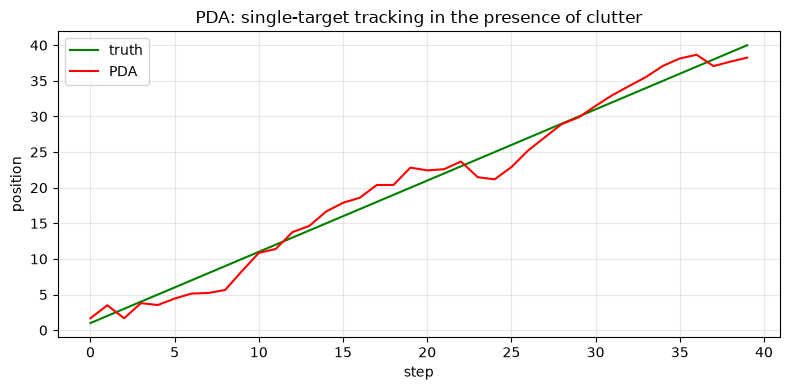

RMSE = 1.73


In [3]:
def pda_update(x, P, F, H, Q, R, zs, PD=0.9, PG=0.99, lam=2e-4):
    x=F@x; P=F@P@F.T+Q                       # predict
    zhat=H@x; S=H@P@H.T+R; K=P@H.T@np.linalg.inv(S)
    if len(zs)==0:
        return x, P, None
    ys=[z-zhat for z in zs]
    norm=1.0/np.sqrt(np.linalg.det(2*np.pi*S))
    Ls=np.array([PD/lam*norm*np.exp(-0.5*float(y@np.linalg.inv(S)@y)) for y in ys])
    b0=1-PD*PG; denom=b0+Ls.sum()
    betas=Ls/denom; beta0=b0/denom
    ybar=sum(b*y for b,y in zip(betas,ys))
    x=x+K@ybar
    # spread of innovations term
    spread=sum(b*np.outer(y,y) for b,y in zip(betas,ys))-np.outer(ybar,ybar)
    Pc=(np.eye(len(x))-K@H)@P
    P=beta0*P+(1-beta0)*Pc+K@spread@K.T
    return x, P, betas

# 1-D moving target, position measurements in clutter
T=1.0; F=np.array([[1,T],[0,1.]]); H=np.array([[1.,0]]); Q=np.array([[.05,.1],[.1,.2]]); R=np.array([[4.]])
x=np.array([0.,1.]); P=np.diag([4.,4.]); true=x.copy()
est=[]; tru=[]
for k in range(40):
    true=F@true; tru.append(true[0])
    zs=[np.array([true[0]+2*rng.standard_normal()])]          # true measurement
    zs+=[np.array([true[0]+rng.uniform(-15,15)]) for _ in range(rng.poisson(2))]  # clutter
    x,P,_=pda_update(x,P,F,H,Q,R,zs)
    est.append(x[0])
plt.figure(figsize=(8,4))
plt.plot(tru,'g',label='truth'); plt.plot(est,'r',label='PDA')
plt.title('PDA: single-target tracking in the presence of clutter'); plt.legend(); plt.grid(alpha=.3)
plt.xlabel('step'); plt.ylabel('position'); plt.tight_layout(); plt.show()
print(f'RMSE = {np.sqrt(np.mean((np.array(est)-np.array(tru))**2)):.2f}')

## D. Extensions: JPDA and MHT
* **JPDA** (Joint PDA) — extends PDA to multiple targets, computing joint association probabilities while preventing conflicts.
* **MHT** (Multiple Hypothesis Tracking) — keeps a **tree of association hypotheses** over time and decides retroactively; 
  powerful in dense environments but computationally expensive (requires pruning).
* Modern approaches (such as Meyer's): **belief propagation** on a factor graph for scalable data association.

**Connection to fusion:** correct association is a precondition for every filter (notebook 03) — 'wrong association' is the 
dominant error source in multi-target tracking, more important than the choice of filter itself.

## Summary
* **Gating** prunes candidates via the Mahalanobis distance ($\chi^2$).
* **GNN** = optimal assignment problem (a hard decision).
* **PDA/JPDA** = soft probabilistic weighting of all measurements in the gate; more robust to clutter.
* **MHT** defers the decision and keeps multiple hypotheses.